Data generation

In [1]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from copy import deepcopy
# from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC

# M = 2
# R = np.array([4, 3])

# num_profiles = 2**M
# profiles, profile_map = hasse.enumerate_profiles(M)

# all_policies = hasse.enumerate_policies(M, R)
# num_policies = len(all_policies)

# sigma_00 = None
# mu_00 = np.array([0])
# # mu_00 = np.array([5])
# var_00 = np.array([1])

# # Profile (0, 1)
# sigma_01 = np.array([[1]])
# mu_01 = np.array([-0.1])
# # mu_01 = np.array([10])
# var_01 = np.array([1])

# # Profile (1, 0)
# sigma_10 = np.array([[1, 0]])
# mu_10 = np.array([-0.2, -0.3])
# # mu_10 = np.array([-10, 15])
# var_10 = np.array([1, 1])

# # Profile (1, 1)
# sigma_11 = np.array([[0, 1], [0, np.inf]])
# mu_11 = np.array([0.2, 0.3, -0.1, -0.1])
# # mu_11 = np.array([20, 30, 5, 10])
# var_11 = np.array([1, 1, 1, 1])

# sigma = [sigma_00, sigma_01, sigma_10, sigma_11]
# mu = [mu_00, mu_01, mu_10, mu_11]
# var = [var_00, var_01, var_10, var_11]

In [2]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from copy import deepcopy
# from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC

# M = 3
# R = np.array([4, 3, 3])

# num_profiles = 2**M
# profiles, profile_map = hasse.enumerate_profiles(M)

# all_policies = hasse.enumerate_policies(M, R)
# num_policies = len(all_policies)

# # Profile (0, 0, 0)
# sigma_000 = None
# mu_000 = np.array([0])
# var_000 = np.array([1])

# # Profile (0, 0, 1)
# sigma_001 = np.array([[1]])
# mu_001 = np.array([-20])
# var_001 = np.array([1])

# # Profile (0, 1, 0)
# sigma_010 = np.array([[1]])
# mu_010 = np.array([10])
# var_010 = np.array([1])

# # Profile (0, 1, 1)
# sigma_011 = np.array([[1], [0]])
# mu_011 = np.array([1, -2])
# var_011 = np.array([1, 1])

# # Profile (1, 0, 0)
# sigma_100 = np.array([[0, 1]])
# mu_100 = np.array([0, 25])
# var_100 = np.array([1, 1])

# # Profile (1, 0, 1)
# sigma_101 = np.array([[0, 1], [0, np.inf]])
# mu_101 = np.array([0, 20, 1, -20])
# var_101 = np.array([1, 1, 1, 1])

# # Profile (1, 1, 0)
# sigma_110 = np.array([[0, 1], [1, np.inf]])
# mu_110 = np.array([0, -25])
# var_110 = np.array([1, 1])

# # Profile (1, 1, 1)
# sigma_111 = np.array([[0, 1], [1, np.inf], [0, np.inf]])
# mu_111 = np.array([0, 25, 40, -20])
# var_111 = np.array([1, 1, 1, 1])

# sigma = [sigma_000, sigma_001, sigma_010, sigma_011,
#         sigma_100, sigma_101, sigma_110, sigma_111]

# mu = [mu_000, mu_001, mu_010, mu_011,
#     mu_100, mu_101, mu_110, mu_111]

# var = [var_000, var_001, var_010, var_011,
#     var_100, var_101, var_110, var_111]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC
M = 3
R = np.array([4, 3, 3])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

# Profile (0, 0, 0)
sigma_000 = None
mu_000 = np.array([0])
var_000 = np.array([1])

# Profile (0, 0, 1)
sigma_001 = np.array([[1]])
mu_001 = np.array([-2])
var_001 = np.array([1])

# Profile (0, 1, 0)
sigma_010 = np.array([[1]])
mu_010 = np.array([1])
var_010 = np.array([1])

# Profile (0, 1, 1)
sigma_011 = np.array([[1], [0]])
mu_011 = np.array([1, -2])
var_011 = np.array([1, 1])

# Profile (1, 0, 0)
sigma_100 = np.array([[0, 1]])
mu_100 = np.array([0, 2])
var_100 = np.array([1, 1])

# Profile (1, 0, 1)
sigma_101 = np.array([[0, 1], [0, np.inf]])
mu_101 = np.array([0, 2, 1, -2])
var_101 = np.array([1, 1, 1, 1])

# Profile (1, 1, 0)
sigma_110 = np.array([[0, 1], [1, np.inf]])
mu_110 = np.array([0, -2])
var_110 = np.array([1, 1])

# Profile (1, 1, 1)
sigma_111 = np.array([[0, 1], [1, np.inf], [0, np.inf]])
mu_111 = np.array([0, 2, 4, -2])
var_111 = np.array([1, 1, 1, 1])

sigma = [sigma_000, sigma_001, sigma_010, sigma_011,
            sigma_100, sigma_101, sigma_110, sigma_111]

mu = [mu_000, mu_001, mu_010, mu_011,
        mu_100, mu_101, mu_110, mu_111]

var = [var_000, var_001, var_010, var_011,
        var_100, var_101, var_110, var_111]


In [4]:
policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
pi_policies = {}
pi_pools = {}
for k, profile in enumerate(profiles):

    policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
    unzipped_temp = list(zip(*policies_temp))
    policies_ids_k = list(unzipped_temp[0])
    policies_k = list(unzipped_temp[1])
    policies_profiles[k] = deepcopy(policies_k)
    policies_ids_profiles[k] = policies_ids_k

    profile_mask = list(map(bool, profile))

    # Mask the empty arms
    for idx, pol in enumerate(policies_k):
        policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
    policies_profiles_masked[k] = policies_k

    if np.sum(profile) > 0:
        pi_pools_k, pi_policies_k = extract_pools.extract_pools(policies_k, sigma[k])
        if len(pi_pools_k.keys()) != mu[k].shape[0]:
            print(f"Profile {k}. Expected {len(pi_pools_k.keys())} pools. Received {mu[k].shape[0]} means.")
        pi_policies[k] = pi_policies_k
        # pi_pools_k has indicies that match with policies_profiles[k]
        # Need to map those indices back to all_policies
        pi_pools[k] = {}
        for x, y in pi_pools_k.items():
            y_full = [policies_profiles[k][i] for i in y]
            y_agg = [all_policies.index(i) for i in y_full]
            pi_pools[k][x] = y_agg
    else:
        pi_policies[k] = {0: 0}
        pi_pools[k] = {0: [0]}

In [5]:
def generate_data(mu, var, n_per_pol, all_policies, pi_policies, M):
    num_data = num_policies * n_per_pol
    X = np.zeros(shape=(num_data, M))
    D = np.zeros(shape=(num_data, 1), dtype='int_')
    y = np.zeros(shape=(num_data, 1))

    idx_ctr = 0
    for k, profile in enumerate(profiles):
        policies_k = policies_profiles[k]

        for idx, policy in enumerate(policies_k):
            policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

            pool_id = pi_policies[k][idx]
            mu_i = mu[k][pool_id]
            var_i = var[k][pool_id]
            y_i = np.random.normal(mu_i, var_i, size=(n_per_pol, 1))

            start_idx = idx_ctr * n_per_pol
            end_idx = (idx_ctr + 1) * n_per_pol

            X[start_idx:end_idx, ] = policy
            D[start_idx:end_idx, ] = policy_idx[0]
            y[start_idx:end_idx, ] = y_i

            idx_ctr += 1

    return X, D, y

In [6]:
num_samples_per_feature = 500

np.random.seed(721)
X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
policy_means = loss.compute_policy_means(D, y, num_policies)

In [7]:
H = np.inf
theta = 13
lamb = 1
R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True, bruteforce=False)

(0, 0, 0) 12.030368826815753
Profile (0, 0, 0) has 1 objects in Rashomon set
(0, 0, 1) 12.058771154581057
Adaptive
Profile (0, 0, 1) took 0.001600027084350586 s adaptively
Profile (0, 0, 1) has 2 objects in Rashomon set
(0, 1, 0) 12.058733805947401
Adaptive
Profile (0, 1, 0) took 0.0013689994812011719 s adaptively
Profile (0, 1, 0) has 2 objects in Rashomon set
(0, 1, 1) 12.110226432167856
Adaptive
Profile (0, 1, 1) took 0.005198955535888672 s adaptively
Profile (0, 1, 1) has 4 objects in Rashomon set
(1, 0, 0) 12.089727673487012
Adaptive
Profile (1, 0, 0) took 0.0034110546112060547 s adaptively
Profile (1, 0, 0) has 4 objects in Rashomon set
(1, 0, 1) 12.173944971588377
Adaptive
Profile (1, 0, 1) took 0.01570415496826172 s adaptively
Profile (1, 0, 1) has 8 objects in Rashomon set
(1, 1, 0) 12.172513798995352
Adaptive
Profile (1, 1, 0) took 0.015913963317871094 s adaptively
Profile (1, 1, 0) has 8 objects in Rashomon set
(1, 1, 1) 12.329301267001311
Adaptive
Profile (1, 1, 1) took 0.2

In [8]:
state=[None, 
     AIS.ProfilePart((0,0,1), [[1.]]),
     AIS.ProfilePart((0,1,0), [[1.]]),
     AIS.ProfilePart((0,1,1), [[1.],[1.]]),
     AIS.ProfilePart((1,0,0), [[1., 1.]]),
     AIS.ProfilePart((1,0,1), [[ 1.,  1.],[ 1., np.inf]]),
     AIS.ProfilePart((1,1,0), [[ 1.,  1.],[ 1., np.inf]]),
     AIS.ProfilePart((1,1,1), ([[ 1.,  1.],
       [ 1., np.inf],
       [ 1., np.inf]]))]
# state=[None, 
#      AIS.ProfilePart((0,1), [[1.]]),
#      AIS.ProfilePart((1,0), [[1., 1.]]),
#      AIS.ProfilePart((1,1), [[ 1.,  1.],[ 1., np.inf]])]
AIS.global_loss_raw(
    state=state,                      # list[ProfilePart or raw sigma/None], length = num_profiles
    D=D, y=y,                       # D: (N,1) global policy ids; y: (N,) or (N,1)
    policies=all_policies,                  # list of ALL policies (len = num_policies)
    policy_means=policy_means,               # (num_policies, 2)
    prof_idx_of_policy=prof_idx_of_policy,         # np.ndarray(len=num_policies): profile index for each policy
    M=M,                     # number of features/arms in this profile family
    R=R,
    reg=lamb,
    normalize=0,
    lattice_edges=None,
)

NameError: name 'prof_idx_of_policy' is not defined

In [ ]:
loss_val = [i[1] for i in losses]
np.min(loss_val)

np.float64(24.03468341307218)

In [9]:
anchors = AIS.build_anchor_states(R_set, R_profiles, M, R)
prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

RPS_states = AIS.raggregate_to_states((R_set, R_profiles), profiles)
score_s = AIS.make_score_s_expneg_raw(
    D=D,
    y=y,
    M=M,
    R=R,
    prof_idx_of_policy = prof_idx_of_policy,
    policies=all_policies,
    policy_means=policy_means,
    reg=lamb,
    lattice_edges=None,   # or your edges
    beta=1.0,             # exp(-loss)
    prior_logprob=lambda state: 0.0
)

In [16]:
log_alpha = [score_s(A) for A in anchors]

buckets = AIS.make_p0_buckets_weighted_S0(RPS_states, np.asarray(R,int), log_alpha,
                                      eps1=0.05, eps2=0.25, min_len=1)
log_p0 = lambda z: AIS.log_p0_distance_weighted_S0(z, buckets)

# 3) Run pilot
ladder, ess_ratios = AIS.pilot_adaptive_ladder(
    init_sampler=lambda N: MCMC.init_from_RPS_batch(RPS_states, log_alpha, N, rng_seed=777),
    log_p0=log_p0,
    score_s=score_s,
    N=512,
    ess_target=0.80,
    beta0=0.0, beta1=1.0,
    initial_delta=0.05,
    min_delta=1e-3,
    moves_per_probe=3,   # small mixing at each accepted β (optional)
    min_len=1,
    rng_seed=777
)
print("Adaptive ladder has", len(ladder), "levels; first 10:", ladder[:10])
print("Per-step ESS ratios (len =", len(ess_ratios), "):", ess_ratios[:10])

Adaptive ladder has 7 levels; first 10: [0.   0.05 0.15 0.35 0.55 0.75 1.  ]
Per-step ESS ratios (len = 6 ): [0.9997983242654349, 0.9965602811209874, 0.9736870219436976, 0.956817286777145, 0.9265192489020203, 0.866993632284188]


In [ ]:
# mcmc_res = MCMC.load_mcmc_res("./toy_50000.pkl.gz")

In [ ]:
# log_alpha = [score_s(A) for A in anchors]
# mcmc_res = MCMC.run_mcmc(score_s, RPS_states, log_alpha, n_chains=1, steps=20000, burnin=500, thin=5, seed=2, min_len=1)
# # MCMC.save_mcmc_res(mcmc_res, "./toy_50000.pkl.gz")

In [ ]:
# log_alpha = [score_s(A) for A in anchors]
# res = MCMC.run_mcmc_streaming(RPS_states, log_alpha, score_s, steps=30000, burnin=5000, thin=5,
#                          out_jsonl="mcmc_run1.jsonl", progress_json="mcmc_run1_progress.json")

In [ ]:
# mcmc_res = MCMC.load_mcmc_res_from_jsonl("mcmc_run1.jsonl")

In [ ]:
# cfg = AIS.AISConfig(n_paths=500, n_levels=50, moves_per_level=500, min_len=1, seed=2)
# out_500 = AIS.run_ais_state(
#     anchors=R_set,          # not used by q0, but you may keep for consistency
#     score_s=score_s,        # returns exp(-loss(state)) or similar
#     cfg=cfg,
#     RPS=RPS_states,              # your Rashomon partitions as a list of State
#     R_per=R,  # levels per arm (includes control)
#     eps1=0.5, eps2=0.75
# )

KeyboardInterrupt: 

In [17]:
cfg = AIS.AISConfig(n_paths=300, n_levels=20, moves_per_level=500, min_len=1, seed=2)
out_5 = AIS.run_ais_state_streaming(
    anchors=R_set,          # not used by q0, but you may keep for consistency
    score_s=score_s,        # returns exp(-loss(state)) or similar
    cfg=cfg,
    RPS=RPS_states,              # your Rashomon partitions as a list of State
    R_per=R,  # levels per arm (includes control)
    eps1=0.5, eps2=0.75,
    out_jsonl = "AIS_samples2.jsonl",
    ladder=ladder
)

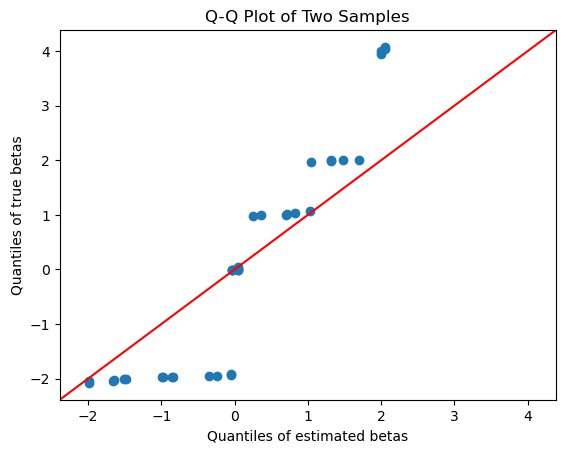

In [18]:
mu_hat = AIS.estimate_policy_means_from_ais(
    ais_out=out_5,                 # from your run_ais_state
    all_policies=all_policies,
    policy_means=policy_means,
    prof_idx_of_policy=prof_idx_of_policy,
    lattice_edges=None,                  # or the hasse edges if you use them
    R_per = R,
    M=M
)

AIS.mu_qqplot(mu_hat, policy_means[:,0]/policy_means[:,1])

In [73]:
def estimate_policy_means_from_RPS(
    RPS_states,                     # dict with key "samples": List[State]
    log_alpha,
    policies,                     # global policy list (length P)
    policy_means,                 # np.ndarray [P,2] = [sum_y, count]
    prof_idx_of_policy,           # length-P array: policy_id -> profile k, for 36 policies, which profile is each policy in
    R_per,                        # np.ndarray of arm levels (includes control)
    M,
    lattice_edges=None            # optional lattice; pass None if unused
):
    """
    Posterior-weighted mean outcome per policy using MCMC samples.
    Weights default to uniform over retained samples.
    Returns: np.ndarray [P]
    """
    samples = RPS_states
    if len(samples) == 0:
        return np.zeros(len(policies), float)

    P = len(policies)
    mu_hat = np.zeros(P, dtype=float)

    # uniform weights over MCMC samples (empirical posterior)
    w = [i/sum(log_alpha) for i in log_alpha]

    # build profile→global index map once
    K = int(np.max(prof_idx_of_policy)) + 1
    prof_to_global = [[] for _ in range(K)]
    for pid in range(P):
        prof_to_global[prof_idx_of_policy[pid]].append(pid)

    # per-profile slices (fixed order defines local indices)
    prof_policies  = [[policies[i] for i in idxs] for idxs in prof_to_global]
    prof_means_arr = [
        policy_means[np.array(idxs, int), :] if idxs else np.zeros((0, 2))
        for idxs in prof_to_global
    ]

    R_per = np.asarray(R_per, int)  # ensure array for assemble

    for x_state, ww in zip(samples, w):
        for k in range(K):
            idxs = prof_to_global[k]
            if not idxs:
                continue

            # expand compact profile matrix to full-width expected by extract_pools
            sigma_full_k = AIS.assemble_sigma_full_for_profile(x_state[k], M, R_per)

            # pools + policy→pool mapping on the *local* list for profile k
            pi_pools_k, pi_policies_k = extract_pools.extract_pools(prof_policies[k], sigma_full_k, lattice_edges)
            mu_pools_k = loss.compute_pool_means(prof_means_arr[k], pi_pools_k)

            # IMPORTANT: pi_policies_k is keyed by LOCAL INDEX, not policy tuple
            for local_idx, pid in enumerate(idxs):
                pool_id = pi_policies_k[local_idx]
                mu_hat[pid] += ww * mu_pools_k[pool_id]

    return mu_hat

In [75]:
RPS_mean = estimate_policy_means_from_RPS(
    RPS_states,                     # dict with key "samples": List[State]
    log_alpha,
    all_policies,                     # global policy list (length P)
    policy_means,                 # np.ndarray [P,2] = [sum_y, count]
    prof_idx_of_policy,           # length-P array: policy_id -> profile k, for 36 policies, which profile is each policy in
    R,                        # np.ndarray of arm levels (includes control)
    M,
    lattice_edges=None            # optional lattice; pass None if unused
)

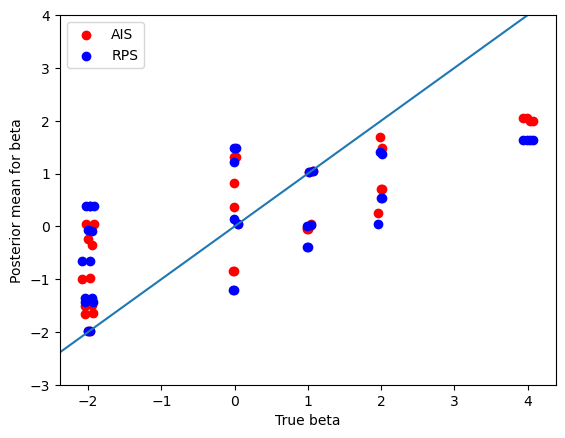

In [83]:

plt.scatter(policy_means[:,0]/policy_means[:,1], mu_hat, color = 'red', label = 'AIS')
plt.scatter(policy_means[:,0]/policy_means[:,1], RPS_mean, color = 'blue', label = 'RPS')
plt.axline((0,0),slope=1)
plt.ylim(-3, 4)  # same y scale
plt.xlabel("True beta")
plt.ylabel("Posterior mean for beta")

plt.legend()
plt.show()

In [68]:
def plot_policy_spread(true_mu, summ, q_low=0.1, q_high=0.9, title="Posterior policy means"):
    # Force 1D arrays
    x    = np.asarray(true_mu, dtype=float).reshape(-1)
    mean = np.asarray(summ["mean"], dtype=float).reshape(-1)
    lo   = np.asarray(summ["quantiles"][q_low], dtype=float).reshape(-1)
    hi   = np.asarray(summ["quantiles"][q_high], dtype=float).reshape(-1)

    # Length check (this is the usual source of "dimension issues")
    P = mean.size
    if not (x.size == P and lo.size == P and hi.size == P):
        raise ValueError(f"Length mismatch: x={x.size}, mean={P}, lo={lo.size}, hi={hi.size}")

    yerr_low = mean - lo
    yerr_hi  = hi - mean

    # Guard invalid / negative intervals
    ok = np.isfinite(x) & np.isfinite(mean) & np.isfinite(yerr_low) & np.isfinite(yerr_hi)
    yerr_low = np.maximum(yerr_low, 0.0)
    yerr_hi  = np.maximum(yerr_hi, 0.0)

    plt.figure()
    plt.errorbar(x[ok], mean[ok], yerr=[yerr_low[ok], yerr_hi[ok]], fmt='o', capsize=2)

    mn = min(x[ok].min(), (mean[ok] - yerr_low[ok]).min())
    mx = max(x[ok].max(), (mean[ok] + yerr_hi[ok]).max())
    plt.plot([mn, mx], [mn, mx], linestyle='--')

    plt.xlabel("True policy mean")
    plt.ylabel("Posterior mean (interval)")
    plt.title(title)
    plt.show()

    zero = ok & (yerr_low == 0) & (yerr_hi == 0)
    print("Zero-width intervals:", int(zero.sum()), "/", int(ok.sum()))

In [10]:
# find the true partition in MCMC samples
# target_by_profile = {
#     0: ((0,0), sigma_00),
#     1: ((0,1), sigma_01),
#     2: ((1,0), sigma_10),
#     3: ((1,1), sigma_11)
# }

# true_sample = MCMC.find_states_matching_targets(mcmc_res,R,M,target_by_profile)
# print(true_sample["fraction"])
# find the RPS states in MCMC samples
mcmc_res = MCMC.load_mcmc_res_from_jsonl("./mcmc_run1.jsonl")

RPS_post = []
for partition in RPS_states:
    target_by_profile = {}
    for i in range(2**M):
        target_by_profile[i] = (partition[i].cov_ids, partition[i].B)
    
    true_sample = MCMC.find_states_matching_targets({"samples": mcmc_res["samples"][15890:]},R,M,target_by_profile)
    # true_sample = MCMC.find_states_matching_targets(mcmc_res,R,M,target_by_profile)
    RPS_post.append(true_sample["fraction"])
    
normalized_RPS_post = [i / sum(RPS_post) for i in RPS_post]

In [11]:
# calculate the exact posterior of RPS states
RPS_post_exact = []

for partition in RPS_states:
    RPS_post_exact.append(score_s(partition))

normalized_RPS_post_exact = [i / sum(RPS_post_exact) for i in RPS_post_exact]

In [12]:
# Enumerate all states and keep score
from rashomon import AIS
losses = AIS.enumerate_all_states_and_losses(
    profiles=profiles,
    R=R,
    M=M,
    policies=all_policies,
    policy_means=policy_means,
    prof_idx_of_policy=prof_idx_of_policy,
    D=D, y=y,
    reg=lamb, normalize=0,
    lattice_edges=None,
    max_states=None  # or an integer cap to safeguard
)

In [13]:
sig = [AIS.state_signature(i[0]) for i in losses]

In [14]:
true_posterior = [np.exp(-i[1]) for i in losses]
norm_true_post = [i/sum(true_posterior) for i in true_posterior]

In [15]:
true_post = []
RPS_test = []
for partition in RPS_states:
    signature = AIS.state_signature(partition)
    idx = sig.index(signature)
    RPS_test.append(true_posterior[idx])
    true_post.append(norm_true_post[idx])

In [19]:
np.sort(norm_true_post)[::-1][0:23]

NameError: name 'norm_true_post' is not defined

In [17]:
RPS_test_norm = [i/sum(RPS_test) for i in RPS_test]

In [19]:
pd.DataFrame({'RPS_estimates_exact':normalized_RPS_post_exact, 'MCMC_estimate': normalized_RPS_post, 'ture posterior': true_post, 'RPS test': RPS_test_norm})

,RPS_estimates_exact,MCMC_estimate,ture posterior,RPS test
0,0.096079,0.000000,0.006032,0.096079
1,0.088693,0.052632,0.005569,0.088693
2,0.039136,0.286550,0.002457,0.039136
3,0.035348,0.000000,0.002219,0.035348
4,0.035347,0.005848,0.002219,0.035347
5,0.035346,0.000000,0.002219,0.035346
6,0.040885,0.011696,0.002567,0.040885
7,0.037742,0.093567,0.002370,0.037742
8,0.036638,0.005848,0.002300,0.036638
9,0.033822,0.040936,0.002124,0.033822


In [32]:
RPS_states[20][7].B

array([[ 1.,  1.],
       [ 1., inf],
       [ 0., inf]])

(0.007526767730308492, 0.1757659281246687)

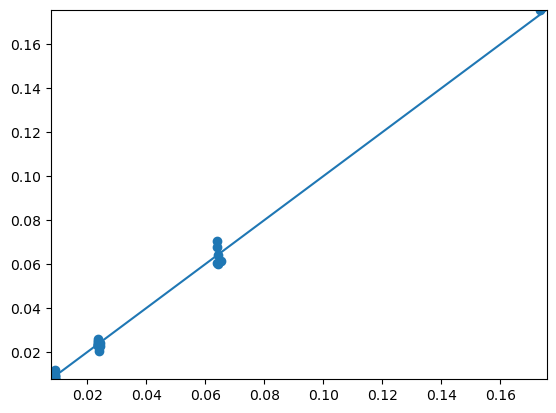

In [66]:
plt.scatter(normalized_RPS_post_exact, normalized_RPS_post) 
x=np.array(normalized_RPS_post_exact)
y=np.array(normalized_RPS_post)
lims = [
    min(x.min(), y.min()),
    max(x.max(), y.max()),
]
plt.plot(lims, lims)   # y = x
plt.xlim(lims)
plt.ylim(lims)

In [34]:
data_generating_partition = []

data_generating_partition.append(AIS.ProfilePart(cov_ids = tuple((0,0)), B = sigma[0]))
data_generating_partition.append(AIS.ProfilePart(cov_ids = tuple((0,1)), B = sigma[1]))
data_generating_partition.append(AIS.ProfilePart(cov_ids = tuple((1,0)), B = sigma[2]))
data_generating_partition.append(AIS.ProfilePart(cov_ids = tuple((1,1)), B = sigma[3]))

In [19]:
for partition in RPS_states:
    if AIS.states_equal(partition, data_generating_partition):
        print("yes")
        signature = AIS.state_signature(partition)
        idx = sig.index(signature)
        print(norm_true_post[idx])


yes
0.014832993449601315


In [30]:
indices = [index for index, value in enumerate(norm_true_post) if value > 0.02]

In [33]:
losses[63][1]

4.375605647248442

In [34]:
for partition in losses:
    if AIS.states_equal(partition[0], data_generating_partition):
        print(partition[1])

4.7497993892940045


In [36]:
losses[63][0][0].B
print(losses[63][0][1].B)
print(losses[63][0][2].B)
print(losses[63][0][3].B)

[[1.]]
[[1. 1.]]
[[ 1.  1.]
 [ 1. inf]]


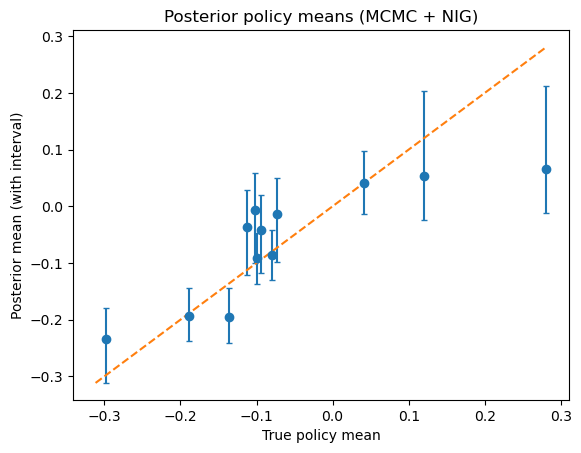

In [10]:
# 1) sample policy-mean draws from MCMC posterior using NIG pool posteriors
draws = MCMC.policy_mean_draws_from_mcmc_nig(
    mcmc_res=mcmc_res,
    D=D, y=y,
    policies=all_policies,
    prof_idx_of_policy=prof_idx_of_policy,
    R_per=R,
    M=M,
    lattice_edges=None,
    n_draws_per_state=1,
    mu0=0.0, kappa0=1.0, alpha0=0.0, beta0=-1.0,
    seed=1
)

# 2) summarize and plot spread vs data-gen truth
summ = MCMC.summarize_policy_draws(draws, qs=(0.1, 0.5, 0.9))
MCMC.plot_policy_spread(policy_means, summ, q_low=0.1, q_high=0.9)


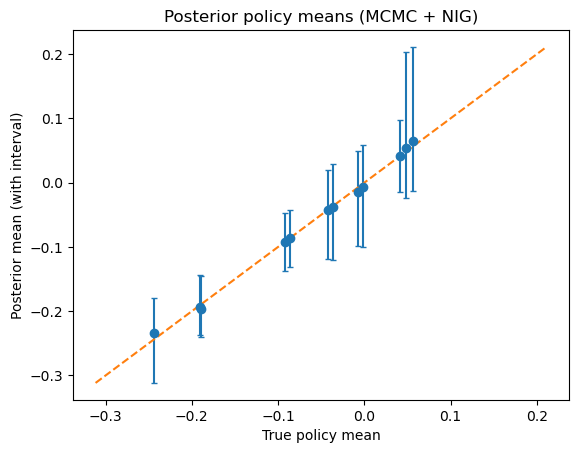

In [32]:
mu_hat_df = np.array([[i for i in mu_hat], [1 for i in mu_hat]]).transpose()
MCMC.plot_policy_spread(mu_hat_df, summ, q_low=0.1, q_high=0.9)

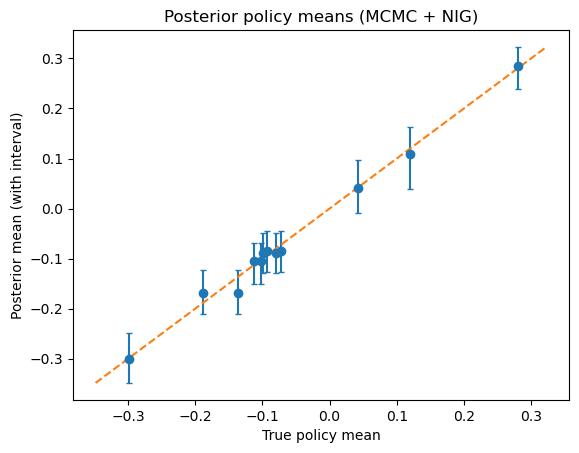

In [41]:
dat_gen_draws = MCMC.policy_mean_draws_from_mcmc_nig(
    mcmc_res={"samples": [data_generating_partition]},
    D=D, y=y,
    policies=all_policies,
    prof_idx_of_policy=prof_idx_of_policy,
    R_per=R,
    M=M,
    lattice_edges=None,
    n_draws_per_state=100,
    mu0=0.0, kappa0=1.0, alpha0=0.0, beta0=-1.0,
    seed=1
)

# 2) summarize and plot spread vs data-gen truth
dat_gen_summ = MCMC.summarize_policy_draws(dat_gen_draws, qs=(0.1, 0.5, 0.9))
MCMC.plot_policy_spread(policy_means, dat_gen_summ, q_low=0.1, q_high=0.9)

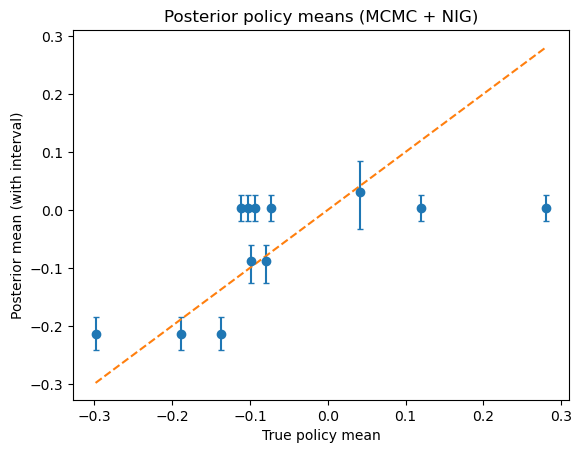

In [46]:
naive_draws = MCMC.policy_mean_draws_from_mcmc_nig(
    mcmc_res={"samples": [losses[63][0]]},
    D=D, y=y,
    policies=all_policies,
    prof_idx_of_policy=prof_idx_of_policy,
    R_per=R,
    M=M,
    lattice_edges=None,
    n_draws_per_state=100,
    mu0=0.0, kappa0=1.0, alpha0=0.0, beta0=-1.0,
    seed=1
)

# 2) summarize and plot spread vs data-gen truth
naive_summ = MCMC.summarize_policy_draws(naive_draws, qs=(0.1, 0.5, 0.9))
MCMC.plot_policy_spread(policy_means, naive_summ, q_low=0.1, q_high=0.9)

In [16]:
mcmc_res["samples"][15890:]

[[<rashomon.AIS.ProfilePart at 0x17bf88990>,
 ...]

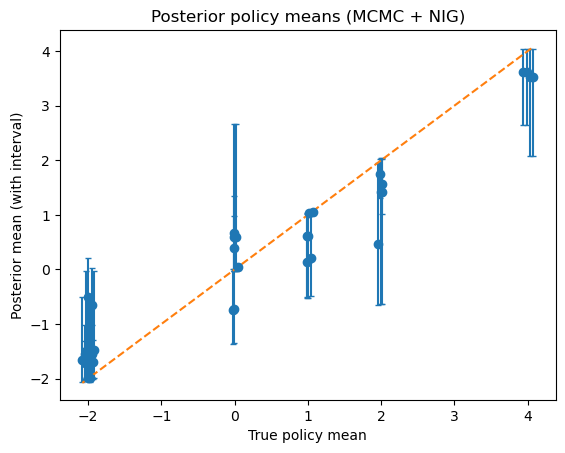

In [28]:
from rashomon import MCMC
mcmc_res = MCMC.load_mcmc_res_from_jsonl("./mcmc_run1.jsonl")

run1 = MCMC.policy_mean_draws_from_mcmc_nig(
    mcmc_res={"samples": mcmc_res["samples"][15890:]},
    D=D, y=y,
    policies=all_policies,
    prof_idx_of_policy=prof_idx_of_policy,
    R_per=R,
    M=M,
    lattice_edges=None,
    n_draws_per_state=100,
    mu0=0.0, kappa0=1.0, alpha0=0.0, beta0=-1.0,
    seed=1
)

# 2) summarize and plot spread vs data-gen truth
summ = MCMC.summarize_policy_draws(run1, qs=(0.1, 0.5, 0.9))
MCMC.plot_policy_spread(policy_means, summ, q_low=0.1, q_high=0.9)